In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [103]:
df = pd.read_csv("Babies.csv")

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Head Length (x1)   25 non-null     int64
 1   Head Breadth (x1)  25 non-null     int64
dtypes: int64(2)
memory usage: 528.0 bytes


In [105]:
df.head()

,Head Length (x1),Head Breadth (x1)
0,191,155
1,195,149
2,181,148
3,183,153
4,176,144


In [106]:
X_train, X_test = train_test_split(df, test_size=.2, random_state = 42)

In [107]:
scaleStandard = StandardScaler()

In [108]:
X_train = scaleStandard.fit_transform(X_train)
X_test = scaleStandard.transform(X_test)

In [109]:
X_train[:5]

array([[ 0.75482075, -0.0142581 ],
       [ 0.55486823,  1.2689707 ],
       [ 1.05474953, -0.15683908],
       [-0.84479938, -1.58264885],
       [ 2.35444089,  0.98380875]])

In [110]:
X_train.mean(axis=0)
X_train.std(axis=0)

array([1., 1.])

In [111]:
pca = PCA()
x_pca = pca.fit(X_train)
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_.T
print(f"Eigenvalues from PCA are {eigenvalues}")
print(f"Eigenvectors from PCA are {eigenvectors}")

Eigenvalues from PCA are [1.79845315 0.30681001]
Eigenvectors from PCA are [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [112]:
eigvalue1 = eigenvalues[0]
eigvector1 = eigenvectors[:,0]
print(f"""First Eigenvalue: {eigvalue1}
First Eigenvector: {eigvector1}""")

First Eigenvalue: 1.798453151733041
First Eigenvector: [0.70710678 0.70710678]


In [113]:
pca_train = pca.transform(X_train)
pca_test = pca.transform(X_test)
pc1_component_train = pca_train[:,0]
pc1_component_test = pca_test[:,0]
print(f"""First Principal Component: 
{pc1_component_train}""")

First Principal Component: 
[ 0.52365687  1.28964888  0.63491857 -1.71646511  2.36049895 -0.45561587
 -0.74883315 -2.83712564  0.18987179 -1.21236523  0.92693678  0.40195346
 -1.45457299 -0.7580758   1.69292879  1.78450611  0.41119611  0.34170129
 -1.68633902  0.3115752 ]


In [114]:
PC1_variance = pca.explained_variance_ratio_[0]
print(f"""Variance explained by PC1:
{PC1_variance}""")

Variance explained by PC1:
0.8542652470731946


In [115]:
eigvalue2 = eigenvalues[1]
eigvector2 = eigenvectors[:,1]
print(f"""Second Eigenvalue: {eigvalue1}
Second Eigenvector: {eigvector1}""")
norm_v2 = np.linalg.norm(eigvector2)
print(f" Eigenvector 2 magnitude is {norm_v2}")
dot_product = np.dot(eigvector1,eigvector2)
print(f" Dot product of th eigenvectors is {dot_product}")

Second Eigenvalue: 1.798453151733041
Second Eigenvector: [0.70710678 0.70710678]
 Eigenvector 2 magnitude is 0.9999999999999999
 Dot product of th eigenvectors is 0.0


In [116]:
pc2_component_train = pca_train[:,1]
pc2_component_test = pca_test[:,1]
print(f"""Second Principal Component: 
{pc2_component_train}""")
PC2_variance = pca.explained_variance_ratio_[1]
print(f"""\n\nVariance explained by PC1:
{PC2_variance}""")

Second Principal Component: 
[-0.54382087  0.5049467  -0.85672252 -0.52173836 -0.96918328  0.03217197
  0.72866916  0.19564226  0.39488407 -0.01763848 -0.14054096  0.1828024
  0.02292932 -0.27028796  0.9082266   0.01008947  1.18175951 -0.16022533
 -0.3502245  -0.3317392 ]


Variance explained by PC1:
0.14573475292680535


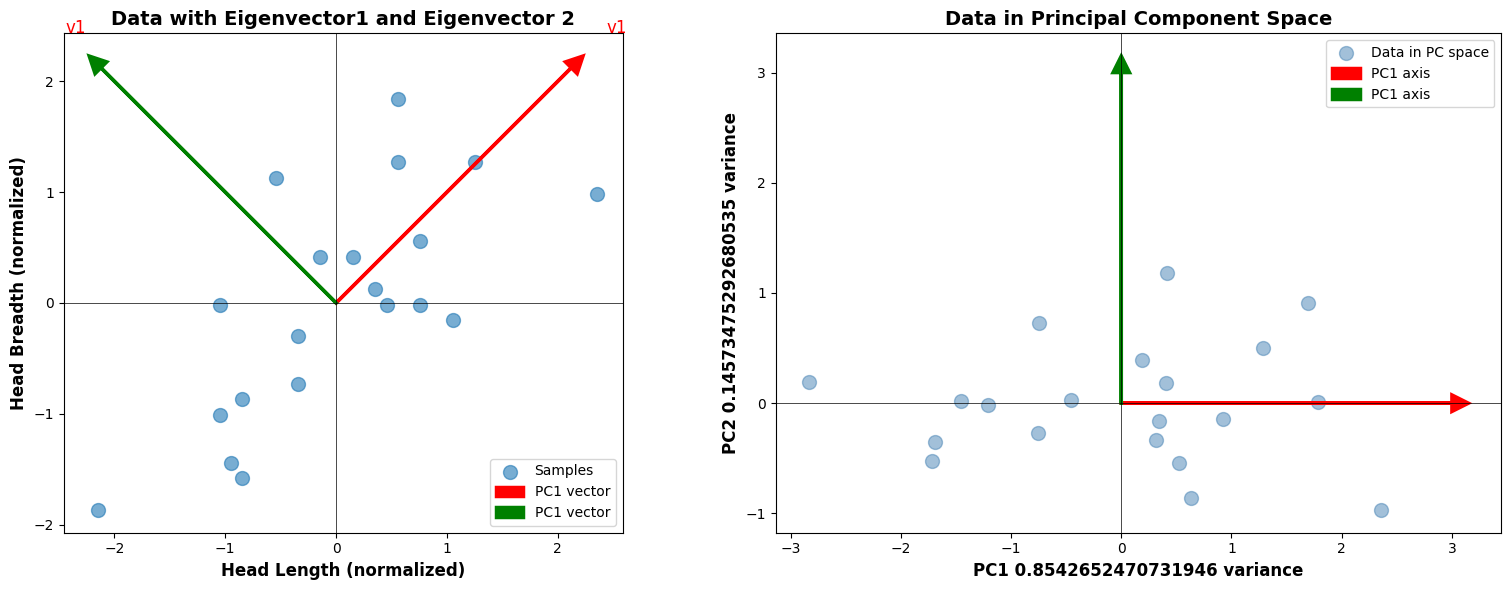

In [117]:
#plot values
# plt.bar(range(1,len(pca1.explained_variance_ratio_)+1), pca1.explained_variance_)

fig, axes = plt.subplots(1,2, figsize=(16,6))
ax1 = axes[0]
ax1.scatter(X_train[:,0], X_train[:,1], alpha=.6, s=100,label = "Samples")

scale = 3
ax1.arrow(0,0,eigvector1[0]*scale,eigvector1[1]*scale,head_width=.15,head_length=.15, fc='red',ec='red',
          linewidth=2.5, label = "PC1 vector")
ax1.arrow(0,0,eigvector2[0]*scale,eigvector2[1]*scale,head_width=.15,head_length=.15, fc='green',ec='green',
          linewidth=2.5, label = "PC1 vector")

ax1.text(eigvector1[0]*scale*1.15, eigvector1[1]*scale*1.15,'v1',fontsize=12,color='red')
ax1.text(eigvector2[0]*scale*1.15, eigvector2[1]*scale*1.15,'v1',fontsize=12,color='red')

ax1.set_xlabel('Head Length (normalized)', fontsize=12,fontweight='bold')
ax1.set_ylabel('Head Breadth (normalized)', fontsize=12,fontweight='bold')
ax1.set_title("Data with Eigenvector1 and Eigenvector 2", fontsize = 14, fontweight = 'bold')
ax1.axhline(y=0, color = 'k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth = 0.5)

# SUBPLOT 2

ax2 = axes[1]

ax2.scatter(pc1_component_train,pc2_component_train, alpha = 0.5, s=100,color= 'steelblue', label= 'Data in PC space')
ax2.arrow(0,0,scale,0,head_width=.15, head_length=.15,fc='red',ec='red',
          linewidth=2.5, label = "PC1 axis")
ax2.arrow(0,0,0,scale,head_width=.15, head_length=.15,fc='green',ec='green',
          linewidth=2.5, label = "PC1 axis")
ax2.set_xlabel(f'PC1 {PC1_variance} variance', fontsize=12,fontweight='bold')
ax2.set_ylabel(f'PC2 {PC2_variance} variance', fontsize=12,fontweight='bold')
ax2.set_title("Data in Principal Component Space", fontsize = 14, fontweight = 'bold')
ax2.axhline(y=0, color = 'k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth = 0.5)
ax2.legend()
ax1.legend()
ax1.set_aspect('equal')
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()